In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [2]:
data = pd.read_csv("defects_data.csv")
data.head(10)

,defect_id,product_id,defect_type,defect_date,defect_location,severity,inspection_method,repair_cost
0,1,15,Structural,6/6/2024,Component,Minor,Visual Inspection,245.47
1,2,6,Functional,4/26/2024,Component,Minor,Visual Inspection,26.87
2,3,84,Structural,2/15/2024,Internal,Minor,Automated Testing,835.81
3,4,10,Functional,3/28/2024,Internal,Critical,Automated Testing,444.47
4,5,14,Cosmetic,4/26/2024,Component,Minor,Manual Testing,823.64
5,6,17,Functional,5/11/2024,Internal,Moderate,Visual Inspection,788.11
6,7,85,Cosmetic,5/23/2024,Internal,Critical,Manual Testing,33.68
7,8,90,Structural,1/15/2024,Internal,Moderate,Manual Testing,65.56
8,9,30,Structural,1/26/2024,Component,Critical,Manual Testing,848.61
9,10,20,Structural,6/5/2024,Component,Critical,Visual Inspection,478.48


## Observing data

The dataset captures inspection results for damaged products, including key attributes such as defect type, defect location, severity, inspection method, and associated repair costs. From a business analytics perspective, this data enables the analysis of cost drivers and the development of repair cost range estimates based on observable defect characteristics. The analysis will assess different feature combinations to identify the optimal balance between limited upfront information and reliable cost estimation, supporting more informed operational and pricing decisions.

In [3]:
data.describe()

,defect_id,product_id,repair_cost
count,1000.000000,1000.000000,1000.000000
mean,500.500000,50.837000,507.627150
std,288.819436,29.480935,289.623615
min,1.000000,1.000000,10.220000
25%,250.750000,26.000000,270.902500
50%,500.500000,51.000000,506.430000
75%,750.250000,77.000000,759.065000
max,1000.000000,100.000000,999.640000



Frequency for defect_type:
defect_type
Structural    352
Functional    339
Cosmetic      309
Name: count, dtype: int64


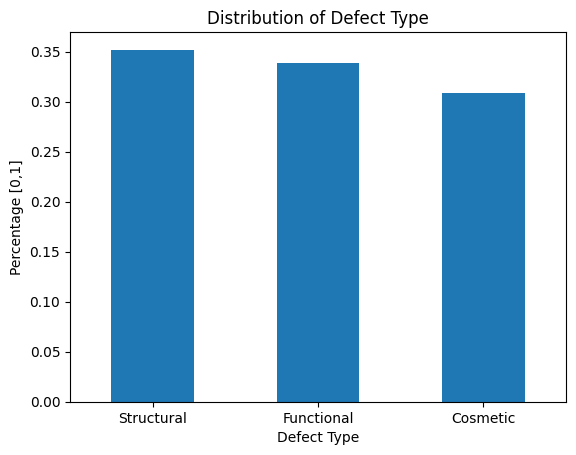


Frequency for defect_location:
defect_location
Surface      353
Component    326
Internal     321
Name: count, dtype: int64


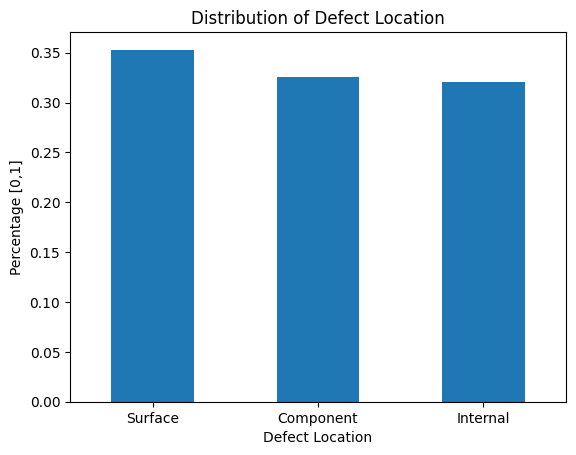


Frequency for severity:
severity
Minor       358
Critical    333
Moderate    309
Name: count, dtype: int64


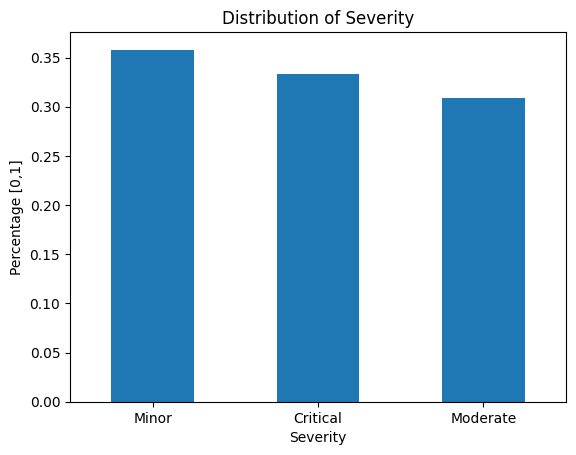


Frequency for inspection_method:
inspection_method
Manual Testing       352
Visual Inspection    351
Automated Testing    297
Name: count, dtype: int64


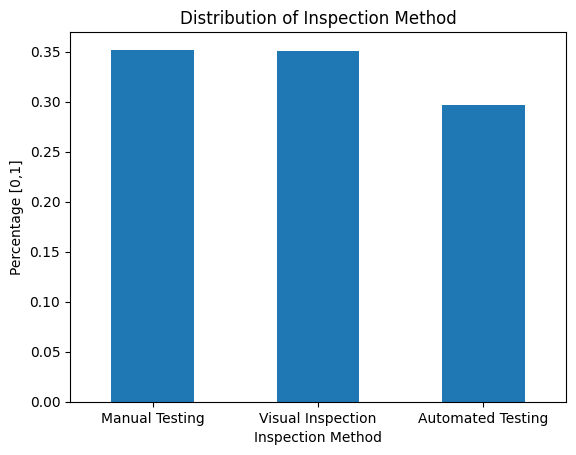

In [4]:
"""
Inspecting the number of product, location, severity, type, inspection methods and their respective frequency

headers = [product_id, defect_type, defect_location, severity, inspection_method]
"""
columns = [
    'defect_type',
    'defect_location',
    'severity',
    'inspection_method'
]

for col in columns:
    print(f"\nFrequency for {col}:")
    print(data[col].value_counts())

    data[col].value_counts(normalize=True).plot(kind='bar')
    plt.title(f'Distribution of {col.replace("_", " ").title()}')
    plt.ylabel('Percentage [0,1]')
    plt.xlabel(col.replace("_", " ").title())
    plt.xticks(rotation=0)
    plt.show()



An initial review of class distribution indicates that no single category exceeds 40% of the dataset, with the largest category accounting for approximately 35%. This suggests that the dataset is reasonably well balanced, providing a solid foundation for reliable interpretation and price range estimation across different feature combinations.

In [5]:
for i in range(len(columns)):
    col1 = columns[i]
    for j in range(i + 1, len(columns)):
        col2 = columns[j]
        print("\nFrequency for " + col1.replace("_", " ") + " and " + col2.replace("_", " ") + ":\n"+"-"*50)
        print(pd.crosstab(data[col1], data[col2]))




Frequency for defect type and defect location:
--------------------------------------------------
defect_location  Component  Internal  Surface
defect_type                                  
Cosmetic                97        95      117
Functional             117       116      106
Structural             112       110      130

Frequency for defect type and severity:
--------------------------------------------------
severity     Critical  Minor  Moderate
defect_type                           
Cosmetic          107    106        96
Functional        114    113       112
Structural        112    139       101

Frequency for defect type and inspection method:
--------------------------------------------------
inspection_method  Automated Testing  Manual Testing  Visual Inspection
defect_type                                                            
Cosmetic                          93             106                110
Functional                        99             124               

Cosmetic defects are most frequently observed on surfaces under Critical and Minor severity levels, while Moderate severity appears slightly under-reported, possibly due to challenges in assessing and classifying defects as Moderate. Defects detected through Automated Testing are generally fewer than those identified via Manual Testing or Visual Inspection, indicating opportunities to expand automation for processes currently reliant on manual or visual assessment.

Regarding severity, the distribution across defect types and locations is relatively balanced but not uniform. Notably, the number of Moderate defects is comparatively low across inspection methods, defect locations, and defect types. This suggests that the definition of Moderate severity may need refinement, as many defects may be more appropriately classified as either Minor or Critical.

Feature interactions:
- Defect type, location, severity, and inspection methods all interact but none are completely predictive alone
- Surface defects tend to be cosmetic and minor. Internal and component defects show higher variation in severity.

Implications for price estimation
- Combining multiple features (defect type + severity + location + inspection methods) will liekly to yield the best repair cost estimation
- Using only a single feature may oversimplify the cost model

C:\Users\dangs\AppData\Local\Temp\ipykernel_4772\4285337600.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


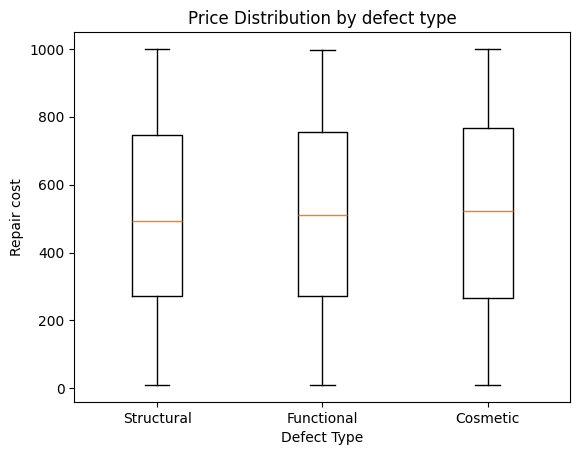

C:\Users\dangs\AppData\Local\Temp\ipykernel_4772\4285337600.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


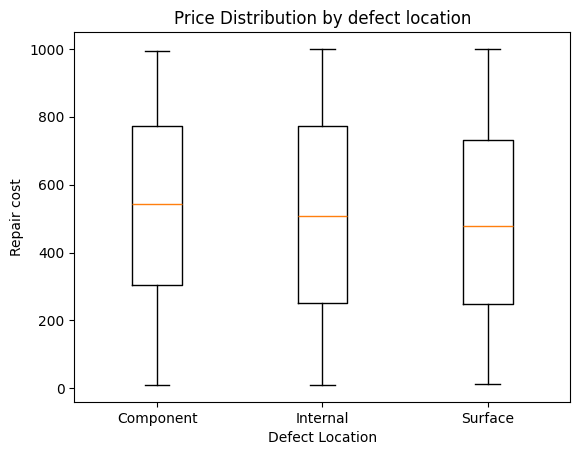

C:\Users\dangs\AppData\Local\Temp\ipykernel_4772\4285337600.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


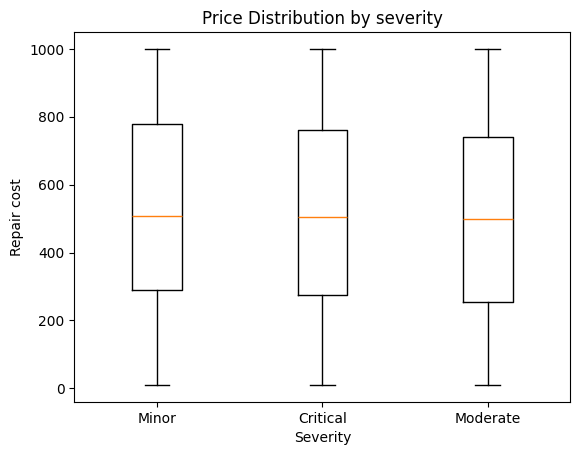

C:\Users\dangs\AppData\Local\Temp\ipykernel_4772\4285337600.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


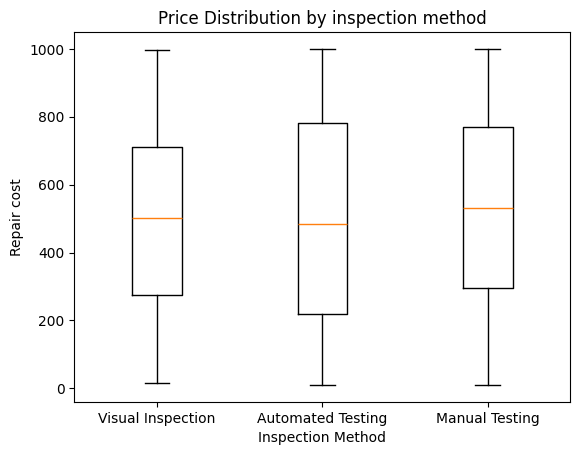

In [6]:
# Whisker box for price range estimation
for category in columns:
    plt.boxplot(
        [data[data[category] == p]['repair_cost'] for p in data[category].unique()],
        labels=data[category].unique()
    )

    plt.title('Price Distribution by ' + category.replace("_", " "))
    plt.ylabel('Repair cost')
    plt.xlabel(category.replace("_", " ").title())
    plt.show()


## Estimating price brackets

Based on the box-and-whisker plots of repair costs across all features (defect type, defect location, severity, and inspection method), the average repair cost is approximately $500, with variability reflected in the Q1 and Q3 bounds for different feature combinations. For practical estimation purposes, repair costs can be categorized into the following brackets:
- From 0 to below 300 $[0,300)$
- From 300 to 500 $[300, 500)$
- From 500 to 800 $[500, 800)$
- Above 800 $[800, \infty)$

These brackets provide a structured framework for assessing expected repair costs based on defect characteristics and inspection methods.

In [7]:
"""
Set brackets for repair cost
"""

bins = [i for i in range(0, 1000, 250)]
bins.append(float('inf'))
labels = [f"[{int(bins[i])},{int(bins[i+1]) if bins[i+1] != float('inf') else '+'})" 
          for i in range(len(bins)-1)]

# Create a new column with categorized repair costs
data['repair_cost_bracket'] = pd.cut(data['repair_cost'], bins=bins, labels=labels, right=False)

# View the first few rows to verify
data.head(10)

,defect_id,product_id,defect_type,defect_date,defect_location,severity,inspection_method,repair_cost,repair_cost_bracket
0,1,15,Structural,6/6/2024,Component,Minor,Visual Inspection,245.47,"[0,250)"
1,2,6,Functional,4/26/2024,Component,Minor,Visual Inspection,26.87,"[0,250)"
2,3,84,Structural,2/15/2024,Internal,Minor,Automated Testing,835.81,"[750,+)"
3,4,10,Functional,3/28/2024,Internal,Critical,Automated Testing,444.47,"[250,500)"
4,5,14,Cosmetic,4/26/2024,Component,Minor,Manual Testing,823.64,"[750,+)"
5,6,17,Functional,5/11/2024,Internal,Moderate,Visual Inspection,788.11,"[750,+)"
6,7,85,Cosmetic,5/23/2024,Internal,Critical,Manual Testing,33.68,"[0,250)"
7,8,90,Structural,1/15/2024,Internal,Moderate,Manual Testing,65.56,"[0,250)"
8,9,30,Structural,1/26/2024,Component,Critical,Manual Testing,848.61,"[750,+)"
9,10,20,Structural,6/5/2024,Component,Critical,Visual Inspection,478.48,"[250,500)"


In [8]:
# Cross tab repair cost bracket with other features
for col in columns:
    print("\nFrequency for repair cost bracket and " + col.replace("_", " ") + ":\n"+"-"*50)
    print(pd.crosstab(data['repair_cost_bracket'], data[col]))


Frequency for repair cost bracket and defect type:
--------------------------------------------------
defect_type          Cosmetic  Functional  Structural
repair_cost_bracket                                  
[0,250)                    72          80          81
[250,500)                  72          87         101
[500,750)                  80          85          83
[750,+)                    85          87          87

Frequency for repair cost bracket and defect location:
--------------------------------------------------
defect_location      Component  Internal  Surface
repair_cost_bracket                              
[0,250)                     64        80       89
[250,500)                   84        78       98
[500,750)                   89        74       85
[750,+)                     89        89       81

Frequency for repair cost bracket and severity:
--------------------------------------------------
severity             Critical  Minor  Moderate
repair_cost_bracket

In [9]:
target_cover = 80
# Calculate the 5th and 95th percentiles
lb = np.percentile(data['repair_cost'], 50-target_cover/2)
ub = np.percentile(data['repair_cost'], 50+target_cover/2)

print(f"Selected range: [0, {lb:.2f}, {(lb+ub)/2:.2f}, {ub:.2f}, 1000]")
coverage = ((data['repair_cost'] >= lb) & (data['repair_cost'] <= ub)).mean() * 100
print(f"Percentage of repair costs within the selected range: {coverage:.2f}%")

# Readjust the bounds to nearest hundreds
bins = [0, lb, (lb+ub)/2, ub,(float('inf'))]
labels = [f"[{int(bins[i])},{int(bins[i+1]) if bins[i+1] != float('inf') else '+'})" 
          for i in range(len(bins)-1)]

# Create a new column with categorized repair costs
data['repair_cost_bracket'] = pd.cut(data['repair_cost'], bins=bins, labels=labels, right=False)
for col in columns:
    col_name = col.replace("_", " ")
    print(f"\nFrequency for repair cost bracket and {col_name} ({target_cover}% coverage): \n" + "-"*50)
    print(pd.crosstab(data['repair_cost_bracket'], data[col]))

Selected range: [0, 94.24, 505.00, 915.77, 1000]
Percentage of repair costs within the selected range: 80.00%

Frequency for repair cost bracket and defect type (80% coverage): 
--------------------------------------------------
defect_type          Cosmetic  Functional  Structural
repair_cost_bracket                                  
[0,94)                     31          37          32
[94,505)                  115         131         153
[505,915)                 131         137         133
[915,+)                    32          34          34

Frequency for repair cost bracket and defect location (80% coverage): 
--------------------------------------------------
defect_location      Component  Internal  Surface
repair_cost_bracket                              
[0,94)                      26        39       35
[94,505)                   123       121      155
[505,915)                  142       127      132
[915,+)                     35        34       31

Frequency for repair co

The repair cost brackets created using an 80% coverage strategy reveal clear patterns in the distribution of costs across different features. The majority of repair costs fall within the mid-range brackets $[94,505)$ and $[505,915)$, while the lowest $[0,94)$ and highest $[915,+)$ brackets capture extreme low-cost and high-cost repairs. These extremes likely correspond to very minor damages and severe defects, respectively, and warrant further investigation to understand the factors driving unusually low or high repair costs.

Examining repair costs by defect type shows that Cosmetic defects are mostly concentrated in the mid-range brackets, whereas Functional and Structural defects are also well represented in the higher-cost brackets. This suggests that certain defect types, particularly Functional and Structural defects, are associated with higher repair costs, which can inform pricing models and resource allocation.

Analysis by defect location indicates that Surface defects tend to cluster in the moderate-cost bracket $[94,505)$, while Component and Internal defects appear more evenly across mid and high-cost brackets. This highlights that internal or component-level damage may drive higher repair costs, reinforcing the importance of prioritizing inspections and maintenance for these areas.

Severity analysis reveals that Moderate and Minor defects are primarily found in the middle-cost brackets, whereas Critical defects span the full range, including the highest-cost bracket $[915,+)$. This suggests that the “Critical” severity classification aligns with more expensive repairs, though further validation is needed to confirm that severity consistently reflects actual cost impact.

Finally, the distribution of repair costs across inspection methods shows that Manual Testing and Visual Inspection capture most mid-range repair costs, while Automated Testing is more frequent in lower-cost brackets. This may indicate that automated methods underreport higher-cost defects, highlighting an opportunity to enhance automation for detecting more costly issues.

Overall, these insights demonstrate that repair cost is influenced by a combination of defect type, location, severity, and inspection method. While no single feature fully explains cost variation, analyzing their interactions provides valuable guidance for predictive modeling, cost estimation, and optimizing inspection strategies for more efficient and accurate defect detection.



In [10]:
for target_cover in [69, 72, 80, 86, 95]:
    # Calculate percentiles
    lb = np.percentile(data['repair_cost'], 50 - target_cover/2)
    ub = np.percentile(data['repair_cost'], 50 + target_cover/2)

    print(f"\nSelected range: [0, {lb:.2f}, {(lb+ub)/2:.2f}, {ub:.2f}, 1000]")
    coverage = ((data['repair_cost'] >= lb) & (data['repair_cost'] <= ub)).mean() * 100
    print(f"Percentage of repair costs within the selected range: {coverage:.2f}%")

    # Adjust bounds to nearest hundreds
    bins = [0, lb, (lb+ub)/2, ub, float('inf')]
    labels = [f"[{int(bins[i])},{int(bins[i+1]) if bins[i+1] != float('inf') else '+'})"
              for i in range(len(bins)-1)]

    # Categorize repair cost
    data['repair_cost_bracket'] = pd.cut(data['repair_cost'], bins=bins, labels=labels, right=False)

    # Normalize by price bracket
    bracket_counts = data['repair_cost_bracket'].value_counts(normalize=True).sort_index()
    print("\nNormalized distribution across repair cost brackets:")
    print(bracket_counts)



Selected range: [0, 149.92, 504.50, 859.07, 1000]
Percentage of repair costs within the selected range: 69.00%

Normalized distribution across repair cost brackets:
repair_cost_bracket
[0,149)      0.155
[149,504)    0.343
[504,859)    0.347
[859,+)      0.155
Name: proportion, dtype: float64

Selected range: [0, 137.31, 510.47, 883.63, 1000]
Percentage of repair costs within the selected range: 72.00%

Normalized distribution across repair cost brackets:
repair_cost_bracket
[0,137)      0.140
[137,510)    0.365
[510,883)    0.355
[883,+)      0.140
Name: proportion, dtype: float64

Selected range: [0, 94.24, 505.00, 915.77, 1000]
Percentage of repair costs within the selected range: 80.00%

Normalized distribution across repair cost brackets:
repair_cost_bracket
[0,94)       0.100
[94,505)     0.399
[505,915)    0.401
[915,+)      0.100
Name: proportion, dtype: float64

Selected range: [0, 67.45, 503.72, 939.98, 1000]
Percentage of repair costs within the selected range: 86.00%

Norm

Best Model Configuration
test_size        0.100000
n_estimators    20.000000
accuracy         0.430000
f1_macro         0.422489
Name: 1, dtype: float64

Final Classification Report (Best Model):
              precision    recall  f1-score   support

   High Cost       0.38      0.30      0.34        33
    Low Cost       0.46      0.42      0.44        31
 Medium Cost       0.43      0.56      0.49        36

    accuracy                           0.43       100
   macro avg       0.43      0.43      0.42       100
weighted avg       0.43      0.43      0.42       100



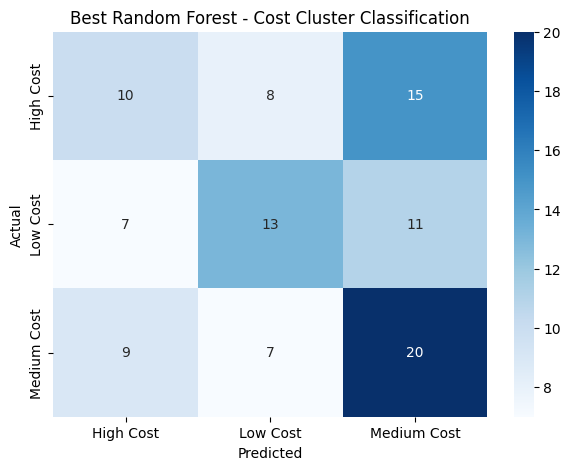

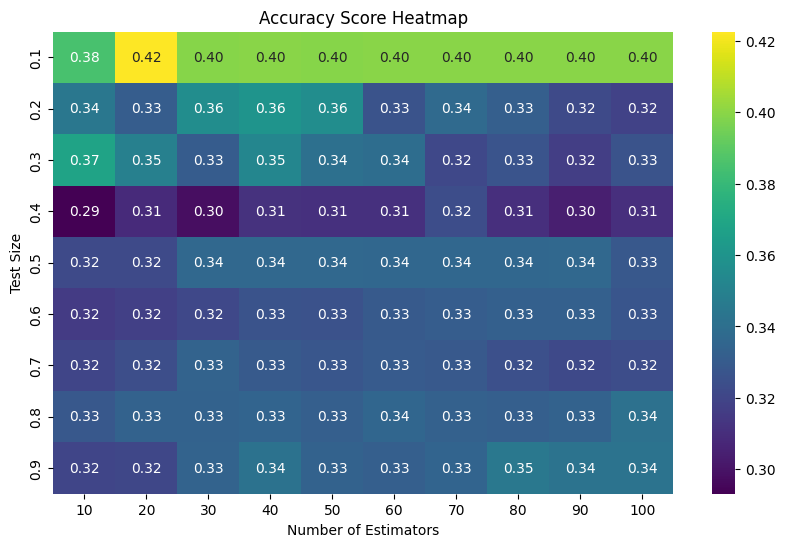

In [11]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

feature_cols = ['defect_type', 'defect_location', 'severity', 'inspection_method']

data_clean = data.copy()

# Choose number of clusters
k = 3

kmeans = KMeans(n_clusters=k, random_state=42)
data_clean['cost_cluster'] = kmeans.fit_predict(data_clean[['repair_cost']])

cluster_means = (
    data_clean.groupby('cost_cluster')['repair_cost']
    .mean()
    .sort_values()
)

cluster_order = {old: new for new, old in enumerate(cluster_means.index)}

data_clean['cost_cluster_ordered'] = data_clean['cost_cluster'].map(cluster_order)

cluster_labels = ['Low Cost', 'Medium Cost', 'High Cost']
data_clean['repair_cost_bracket'] = data_clean['cost_cluster_ordered'].map(
    {i: cluster_labels[i] for i in range(len(cluster_labels))}
)


X = pd.get_dummies(data_clean[feature_cols])
y = data_clean['repair_cost_bracket']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

results = []

for test_size in range(1, 10):
    for num_estimators in range(10, 110, 10):

        X_train, X_test, y_train, y_test = train_test_split(
            X, y_encoded,
            test_size=test_size / 10,
            stratify=y_encoded,
            random_state=42
        )

        rf = RandomForestClassifier(
            n_estimators=num_estimators,
            max_depth=200,
            random_state=42
        )

        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='macro')

        results.append({
            'test_size': test_size / 10,
            'n_estimators': num_estimators,
            'accuracy': acc,
            'f1_macro': f1
        })

results_df = pd.DataFrame(results)

# Best model by macro F1
best_row = results_df.sort_values('accuracy', ascending=False).iloc[0]

best_test_size = best_row['test_size']
best_estimators = best_row['n_estimators']

print("Best Model Configuration")
print(best_row)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=best_test_size,
    stratify=y_encoded,
    random_state=42
)

best_rf = RandomForestClassifier(
    n_estimators=int(best_estimators),
    max_depth=200,
    random_state=42
)

best_rf.fit(X_train, y_train)
y_pred = best_rf.predict(X_test)

print("\nFinal Classification Report (Best Model):")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Best Random Forest - Cost Cluster Classification")
plt.show()

importances = pd.Series(best_rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(15)

pivot_f1 = results_df.pivot(
    index='test_size',
    columns='n_estimators',
    values='f1_macro'
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot_f1, annot=True, fmt=".2f", cmap="viridis")
plt.title("Accuracy Score Heatmap")
plt.ylabel("Test Size")
plt.xlabel("Number of Estimators")
plt.show()


In [13]:
print("Feature Importances:")
for idx, (name, score) in enumerate(zip(best_rf.feature_names_in_, best_rf.feature_importances_*100), start=1):
    print(f"{idx}: {name} - {round(score,2)}%")

Feature Importances:
1: defect_type_Cosmetic - 10.94%
2: defect_type_Functional - 8.8%
3: defect_type_Structural - 8.39%
4: defect_location_Component - 7.68%
5: defect_location_Internal - 5.16%
6: defect_location_Surface - 8.37%
7: severity_Critical - 8.67%
8: severity_Minor - 10.37%
9: severity_Moderate - 7.22%
10: inspection_method_Automated Testing - 6.6%
11: inspection_method_Manual Testing - 9.84%
12: inspection_method_Visual Inspection - 7.95%


Overall predictive power is over the baseline of 1/3 of the chances of guessing between low, medium and high cost, which indicates there are correleations between these feasures that affecting the repair cost range. The best-performing model achieves accuracy of 43% and macro F1 of 42%. Defect type, locaiton, severity, and inspection method do not contain signal about repair cost, but they do not fully explain price variation.

> The available features are directionally informative but insufficient on their own to precisely determine the repair cost bracket

From the classification report and confusion matrix, medium cost has the highest recall (56%) and many low and high cost cases are misclassified as medicum cost

> Medium repair cost cases share characterisitcs with both low and high cost cases. The features do not cleanly separate extreme costs -> There are factors not included in this dataset drive the repair cost

High repair are frequently misclassified as medium cost cases, which means high repair costs are likely to be influenced by hidden damage, lobor intensity, part availablity and escalation desisions after inspection (not included in the current dataset)

Low cosr repairs are predicted more consistently, but still imperfect. Cosmetic or minor defects are easier to identify, but some cases that appear simple still incur higher costs, which pointing to factors that are not included in this defect description.

The best-performing model has a small test size and few estimators with a moderate performance. Increasing the test size, number of estimators or branches to fine tune the model create a diminishing return to performance improvements. It means it is a feature limitation problem not a model problem. There is no features that strongly discriminate between cases

## Feature Importance Analysis

The feature importance results show that repair cost brackets are influenced more by how defects are classified and inspected than by the physical characteristics of the defects themselves. Among all variables, defect type and severity dominate the model’s decision-making process. In particular, cosmetic defects and minor severity levels emerge as the most influential predictors. This suggests that these categories occur frequently and carry consistent cost implications, making them easier for the model to learn and use when distinguishing between cost tiers. Rather than signaling high repair complexity, these features help the model identify routine, lower-to-medium cost repair patterns.

Inspection method also plays a significant role in predicting repair cost brackets, with manual testing ranking higher than both automated testing and visual inspection. This indicates that the inspection process itself acts as a proxy for repair effort and cost. Manual testing is likely associated with increased labor time, diagnostic complexity, or follow-up actions, all of which contribute to higher repair costs. As a result, inspection method captures operational intensity rather than simply defect detection, reinforcing the idea that process-related factors are critical drivers of repair cost outcomes.

Severity levels contribute meaningfully to cost prediction, but their influence is not linear. Minor severity appears to be more informative than critical or moderate severity, suggesting that minor defects tend to follow predictable repair pathways with relatively stable costs. In contrast, critical defects span a wide range of outcomes (from quick fixes to extensive repairs) reducing their usefulness as a consistent cost indicator. Moderate severity shows the weakest contribution, which may point to ambiguity or inconsistency in how this category is defined and applied during inspections.

Defect location contributes to cost prediction but remains secondary compared to defect type, severity, and inspection method. While component, internal, and surface defects each carry distinct repair implications, location alone does not strongly determine the final cost bracket. This reinforces the idea that where a defect occurs is less important than how it is evaluated and addressed within the repair process.

Taken together, these insights explain why the model performs reasonably well at identifying low- and medium-cost repairs but struggles to reliably predict high-cost cases. High-cost repairs are often driven by hidden or downstream factors—such as labor hours, parts availability, or escalation decisions—that are not captured in the current dataset. Consequently, the model tends to group ambiguous or extreme cases into the medium-cost category, reflecting the limits of the available information rather than a modeling deficiency.

In summary, the analysis shows that repair cost predictability is shaped more by inspection practices and classification decisions than by defect characteristics alone. While the model can support early-stage cost tiering and operational prioritization, it is not sufficient for precise cost estimation without additional process- and resource-level data. These findings highlight the importance of improving inspection consistency and enriching datasets with operational cost drivers to achieve more accurate and actionable repair cost predictions.
